# 00 · Quickstart — rodar todas as configurações do sistema

Notebook de **uso** (não é um estudo): exercita, de forma intuitiva, **cada capacidade** do
NeuraTrade, sempre mostrando a chamada em Python e o atalho de script/CLI quando existe.

1. **Pipeline de detecção** (univariada, default) — `python -m src`
2. **Trocar a agregação do erro** — `mean` / `max` / `percentile` (ADR-0009)
3. **Detecção multivariada** Close+Volume + atribuição por canal (ADR-0011)
4. **Contexto macro** — distinguir anomalia **idiossincrática** vs **sistêmica** (Conditional AE, ADR-0012)
5. **Inferência em janela nova** (fora do treino) — `scripts/run_inference.py`
6. **Mapa de configurações** (o que mudar e onde)

A lógica vive em `src/`; aqui só orquestramos. Pré-requisito: `data/raw/` (versionado) e, para a
detecção, modelos em `models/` — as células treinam sozinhas se faltarem.

## Setup

In [1]:
# Colab: !git clone https://github.com/Cerne17/NeuraTrade.git ; %cd NeuraTrade ; !pip install -e .
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import CONFIG, set_seeds
set_seeds()
TICKERS = CONFIG["tickers"]
print("tickers:", TICKERS)
print("config atual → agregação:", CONFIG["detection"]["aggregation"],
      "| features multivariadas:", CONFIG["preprocessing"]["features"],
      "| macro:", CONFIG["macro"]["features"])

tickers: ['PETR4.SA', 'VALE3.SA', 'AMER3.SA', 'ITUB4.SA']
config atual → agregação: max | features multivariadas: ['Close', 'Volume'] | macro: ['USDBRL', 'VIX']


## 1. Pipeline de detecção (univariada, default)

`run_pipeline` encadeia tudo (dados → pré-processamento → carrega/treina → detecção estática e
dinâmica → avaliação sintética) para os 4 ativos, com a config atual (agregação `max`).

**CLI equivalente:** `python -m src` (ou `--train` na 1ª vez).

In [2]:
from src.pipeline import run_pipeline, summarize

try:
    resultados = run_pipeline(train=False, evaluate=True)   # carrega models/
except FileNotFoundError:
    resultados = run_pipeline(train=True, evaluate=True)     # 1ª vez: treina
summarize(resultados)

,agregacao,n_test_windows,limiar_estatico,frac_estatico,frac_dinamico,precision,recall,f1
ticker,,,,,,,,
PETR4.SA,max,1215,0.40772,0.0584,0.0568,0.768,0.133,0.227
VALE3.SA,max,1215,0.2631,0.028,0.0856,0.934,0.537,0.682
AMER3.SA,max,1215,0.2844,0.27,0.1251,0.847,0.559,0.674
ITUB4.SA,max,1215,0.37819,0.056,0.0543,0.821,0.174,0.287


## 2. Trocar a agregação do erro (mean / max / percentile)

O erro de uma janela pode ser agregado por `mean` (histórico), `max` (default, pega o pior passo)
ou `percentile`. É uma chave de `config.yaml` (`detection.aggregation`), mas dá para comparar na
hora chamando `reconstruction_error` com cada modo. `max`/`percentile` exigem **recalibrar o
limiar** sobre o mesmo escore (ADR-0009).

In [3]:
from src import data, preprocessing as pp, train as T, detect as D

t = "PETR4.SA"
pre = pp.preprocess_ticker(data.load_ticker(t))
model = T.load_model(t)

linhas = []
for agg in ["mean", "max", "percentile"]:
    err_tr = D.reconstruction_error(model, pre["X_train"], aggregation=agg)
    err_te = D.reconstruction_error(model, pre["X_test"],  aggregation=agg)
    thr = D.static_threshold(err_tr)                      # limiar recalibrado p/ cada agregação
    frac = float(np.mean(D.flag_anomalies(err_te, thr)))
    linhas.append({"agregacao": agg, "limiar": round(thr, 4), "frac_marcada_teste": round(frac, 3)})
print(f"{t}: efeito da agregação (limiar recalibrado por modo)")
pd.DataFrame(linhas).set_index("agregacao")

PETR4.SA: efeito da agregação (limiar recalibrado por modo)


,limiar,frac_marcada_teste
agregacao,,
mean,0.1241,0.029
max,0.4077,0.058
percentile,0.2411,0.030


## 3. Detecção multivariada (Close+Volume) + atribuição por canal

Entrada `(30, 2)`: além do preço, o **volume**. O erro vira um vetor por canal —
`reconstruction_error_per_channel` diz se a anomalia foi de **preço** ou de **volume** (ADR-0011).
Treina o modelo `_multi` se não houver.

In [4]:
mv = pp.preprocess_ticker_multivariate(data.load_ticker(t))   # features = config (Close, Volume)
try:
    model_mv = T.load_model(t, suffix="_multi")
except FileNotFoundError:
    model_mv, _ = T.train_model(mv["X_train"], ticker=t, suffix="_multi", verbose=0)

per_canal = D.reconstruction_error_per_channel(model_mv, mv["X_test"], aggregation="max")
print(f"{t}: erro médio por canal no teste (max-pooled)")
pd.Series(per_canal.mean(axis=0), index=mv["features"]).round(4)

PETR4.SA: erro médio por canal no teste (max-pooled)


Close     0.2226
Volume    0.0708
dtype: float32

## 4. Contexto macro: idiossincrático vs sistêmico (Conditional AE)

A capacidade-estrela (ADR-0012): a macro (USD/BRL, VIX) **condiciona** o encoder mas não entra na
loss; dois escores por bloco separam **estresse do ativo** (`pv_error`) de **choque de mercado**
(`macro_stress`). Treina um Conditional AE por ativo (rápido) e classifica cada janela de teste.

**Prova:** COVID/2020 → sistêmico; fraude Americanas/2023 → idiossincrático.

In [5]:
import collections
from src.macro import load_macro
from src.conditional import (conditional_features, prepare_conditional, train_conditional,
                             block_scores, block_thresholds, classify_regime)

macro = load_macro()           # data/raw/macro.csv (já versionado)
W = CONFIG["preprocessing"]["window_size"]

def regime(ticker):
    frame, n_pv = conditional_features(data.load_ticker(ticker), macro)   # macro = config (USDBRL, VIX)
    prep = prepare_conditional(frame, n_pv)
    m, _ = train_conditional(prep["X_train"], n_pv, verbose=0)
    tr, te = block_scores(m, prep["X_train"], n_pv), block_scores(m, prep["X_test"], n_pv)
    pv_thr, m_thr = block_thresholds(tr)
    lab = classify_regime(te["pv_error"], te["macro_stress"], pv_thr, m_thr)
    return pd.Series(lab, index=prep["test_index"][W-1:W-1+len(lab)])

r_petr, r_amer = regime("PETR4.SA"), regime("AMER3.SA")
print("PETR4 · COVID 2020 (mar-mai):", dict(collections.Counter(r_petr["2020-03-01":"2020-05-31"])))
print("AMER3 · Americanas jan-2023 :", dict(collections.Counter(r_amer["2023-01-01":"2023-03-31"])))

PETR4 · COVID 2020 (mar-mai): {'normal': 32, 'sistemico': 30}
AMER3 · Americanas jan-2023 : {'normal': 25, 'idiossincratico': 38}


## 5. Inferência em uma janela nova (fora do treino)

Aplica os modelos a um intervalo arbitrário (ex.: 2025) **sem retreinar**. Normalização e limiar
continuam os do treino (ADR-0001): "anomalia" = desvio da normalidade aprendida.

**Interativo:** `python scripts/run_inference.py` · **Baixar:** `python scripts/fetch_window.py --start ... --end ...`

In [6]:
from src.inference import fetch_window, infer_all

START, END = "2025-01-01", "2025-06-30"
janela = fetch_window(TICKERS, START, END)                   # rede (yfinance)
infer = infer_all(TICKERS, START, END, window_data=janela)
resumo = pd.DataFrame({
    t: {"janelas": len(df), "anomalias": int(df["anomalia"].sum())} for t, df in infer.items()
}).T
print(f"Inferência {START} → {END}:")
print(resumo)

Inferência 2025-01-01 → 2025-06-30:
          janelas  anomalias
PETR4.SA       91          0
VALE3.SA       91          0
AMER3.SA       91         30
ITUB4.SA       91          0


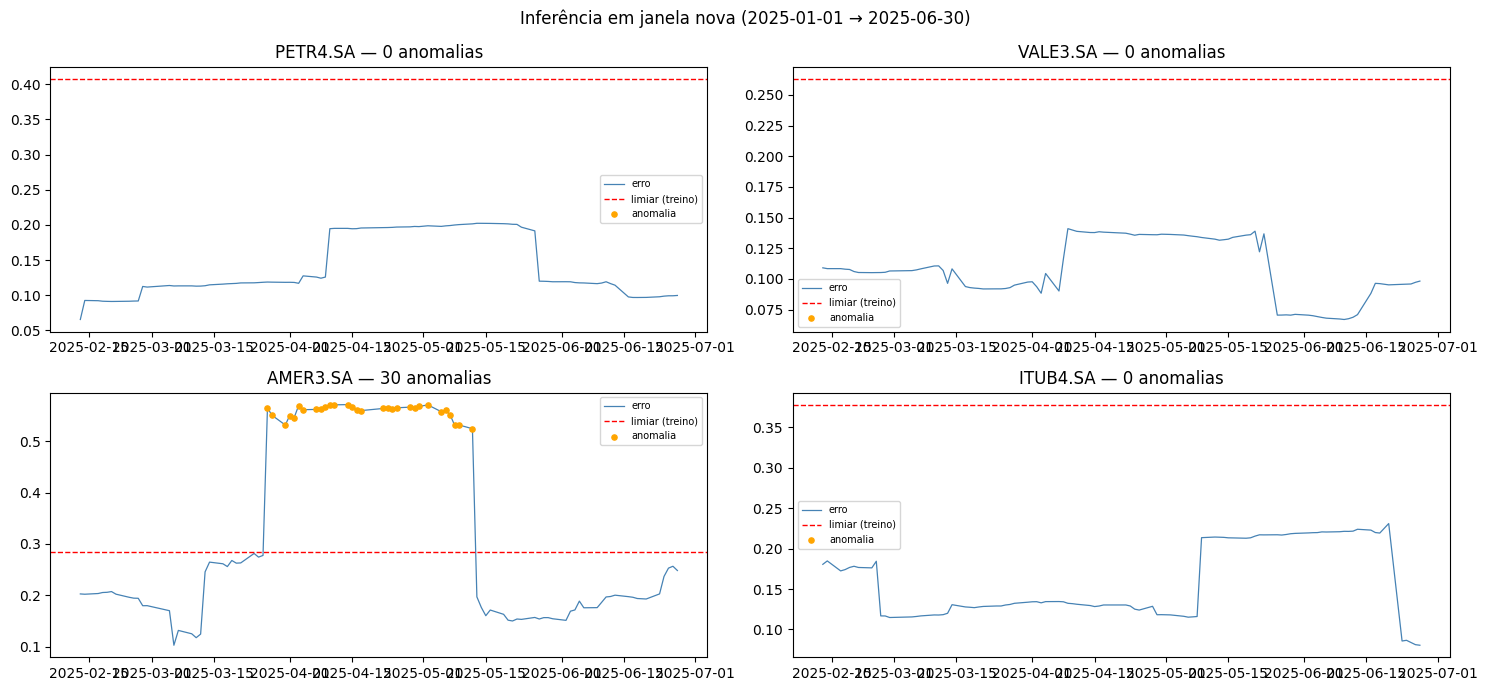

In [7]:
from src.viz import save_fig

fig, axes = plt.subplots(2, 2, figsize=(15, 7))
for ax, tk in zip(axes.ravel(), TICKERS):
    d = infer[tk]
    ax.plot(d.index, d["erro"], lw=0.9, color="steelblue", label="erro")
    ax.axhline(d["limiar"].iloc[0], color="red", ls="--", lw=1, label="limiar (treino)")
    an = d[d["anomalia"]]
    ax.scatter(an.index, an["erro"], color="orange", s=14, zorder=5, label="anomalia")
    ax.set_title(f"{tk} — {int(d['anomalia'].sum())} anomalias"); ax.legend(fontsize=7)
fig.suptitle(f"Inferência em janela nova ({START} → {END})")
fig.tight_layout(); save_fig(fig, "quickstart_inferencia_2025"); plt.show()

## 6. Mapa de configurações — o que mudar e onde

Tudo é dirigido por `config.yaml` (fonte única). Editar lá muda o comportamento de toda a pipeline.

| Capacidade | Chave em `config.yaml` | Valores | ADR |
| --- | --- | --- | --- |
| Agregação do erro | `detection.aggregation` | `mean` / **`max`** / `percentile` | 0009 |
| Limiar | `detection.threshold_percentile`, `dynamic_window` | 95, 252 | 0005 |
| Features multivariadas | `preprocessing.features` | `[Close, Volume]` | 0011 |
| Gargalo | `model.latent_dim` | 16 | 0003/0010 |
| Folds walk-forward | `validation.n_splits` | 10 (Kohavi) | 0010 |
| Macro (contexto) | `macro.features` | `[USDBRL, VIX]` | 0012 |

| Tarefa | Python | Script / CLI |
| --- | --- | --- |
| Pipeline completa | `run_pipeline()` | `python -m src` |
| Treinar do zero | `run_pipeline(train=True)` | `python -m src --train` |
| Baixar janela nova | `fetch_window(...)` | `python scripts/fetch_window.py --start ... --end ...` |
| Inferência interativa | `infer_all(...)` | `python scripts/run_inference.py` |
| Recriar cache (ações+macro) | — | `python scripts/cache_data.py` |
| Regenerar figuras | — | `python scripts/build_figures.py` |

> **Estudos aprofundados** (seleção de `latent_dim` por walk-forward, OHLCV completo, calibração
> da agregação, regime macro) estão nos notebooks numerados 01–13 — ver `notebooks/README.md`.